# Dependencies

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# !pip -q install kagglehub timm scikit-learn pandas numpy pillow
# !apt -y install git git-lfs >/dev/null
# !git lfs install >/dev/null

In [3]:
import os, sys, glob, json, csv, time, math, pathlib, random
from collections import OrderedDict

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import kagglehub
import timm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import top_k_accuracy_score, accuracy_score

import argparse
from collections import OrderedDict

import torch.nn.functional as F

# Github repo clone

In [4]:
# Cloning the Github repo that contains the dataset
REPO_URL = "https://github.com/Brandenn28/ML.git"
CLONE_DIR = "/content/ML"

if not os.path.exists(CLONE_DIR):
    !git clone --depth=1 "{REPO_URL}" "{CLONE_DIR}"
%cd "{CLONE_DIR}"
!git lfs pull

# Base dataset directory in Colab
DATA_ROOT = "/content/ML/AML_project_herbarium_dataset"
PROCESSED_DIR = f"{DATA_ROOT}/processed"

# Processed CSV files required
train_csv = os.path.join(PROCESSED_DIR, "train_v2.csv")
val_csv = os.path.join(PROCESSED_DIR, "val_v2.csv")
test_csv = os.path.join(PROCESSED_DIR, "test.csv")
test_gt_csv = os.path.join(PROCESSED_DIR, "test_with_groundtruth.csv")

required_files = [
    "species_mapping.csv",
    "train_v2.csv",
    "val_v2.csv",
    "test.csv",
    "test_with_groundtruth.csv",
]
missing = [f for f in required_files if not os.path.exists(os.path.join(PROCESSED_DIR, f))]
if missing:
    raise FileNotFoundError(f"Missing processed files: {missing} in {PROCESSED_DIR}")

print("DATA_ROOT:", DATA_ROOT)
print("Processed dir:", PROCESSED_DIR)
print("Processed files sample:", os.listdir(PROCESSED_DIR)[:10])

Cloning into '/content/ML'...
remote: Enumerating objects: 5138, done.
remote: Counting objects: 100% (5138/5138), done.
remote: Compressing objects: 100% (5131/5131), done.
remote: Total 5138 (delta 7), reused 5134 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (5138/5138), 577.33 MiB | 44.40 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Updating files: 100% (4979/4979), done.
/content/ML
DATA_ROOT: /content/ML/AML_project_herbarium_dataset
Processed dir: /content/ML/AML_project_herbarium_dataset/processed
Processed files sample: ['class_counts.csv', 'class_weights.csv', 'val.csv', 'species_mapping.csv', 'test_with_groundtruth.csv', 'train_sample_weights.csv', 'per_class_domain_stats.csv', 'train.csv', 'species_with_pairs.csv', 'test.csv']


##2. Dataset and transforms

In [5]:
# Standard ImageNet normalization & size used for DINOv2
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
NUM_WORKERS = 2
print(f"Running on device: {device}")

# Transformation details for the images for train and evaluation
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class CSVImageDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)

        rel_list = self.df["rel_path"].astype(str).tolist() if "rel_path" in self.df.columns else []
        rel_joined = [os.path.join(DATA_ROOT, p).replace("\\", "/") for p in rel_list]

        if "abs_path" in self.df.columns:
            abs_list = self.df["abs_path"].astype(str).tolist()
        else:
            abs_list = ["" for _ in rel_list]

        paths = []
        for a, r in zip(abs_list, rel_joined):
            a_norm = a.replace("\\", "/")
            p = a_norm if a_norm and os.path.exists(a_norm) else r
            paths.append(p)
        self.paths = paths

        self.labels = self.df["label_idx"].astype(int).tolist() if "label_idx" in self.df.columns else None
        self.domain = self.df["domain"].astype(str).tolist() if "domain" in self.df.columns else None
        self.transform = transform

    def __len__(self):
      return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        img = Image.open(path).convert("RGB")
        x = self.transform(img) if self.transform else img

        # Multiple return modes depending on what columns exist
        if self.labels is not None and self.domain is not None:
            return x, self.labels[i], self.domain[i], path
        elif self.labels is not None:
            return x, self.labels[i], path
            # include getting the domain type
        elif self.domain is not None:
            return x, self.domain[i], path
        else:
            return x, path


Running on device: cuda


# Few-shot class selection (K rarest classes)

In [6]:
# # Few shot configuration
# CLASS_COUNTS_CSV = os.path.join(PROCESSED_DIR, "class_counts.csv")
# class_counts = pd.read_csv(CLASS_COUNTS_CSV)

# FEW_SHOT_THRESHOLD = 3  # or 3, discuss with group
# few_shot_label_indices = class_counts.loc[
#     class_counts["count"] <= FEW_SHOT_THRESHOLD, "label_idx"
# ].tolist()
# normal_label_indices = class_counts.loc[
#     class_counts["count"] > FEW_SHOT_THRESHOLD, "label_idx"
# ].tolist()

# # NUM_CLASSES = class_counts["label_idx"].max() + 1

# print("Few shot classes:", len(few_shot_label_indices))
# print("Normal classes:", len(normal_label_indices))


In [7]:
# Few shot configuration
CLASS_COUNTS_CSV = os.path.join(PROCESSED_DIR, "class_counts.csv")
class_counts = pd.read_csv(CLASS_COUNTS_CSV)

# K rarest classes as "few shot"
K_FEW_SHOT = 10
class_counts_sorted = class_counts.sort_values("count", ascending=True) # Sort classes by increasing count

few_shot_label_indices = class_counts_sorted.head(K_FEW_SHOT)["label_idx"].tolist() # Few shot labels are the first K label_idx values

# All other labels are "normal"
all_labels = class_counts_sorted["label_idx"].tolist()
normal_label_indices = [c for c in all_labels if c not in few_shot_label_indices]

print("Few shot classes:", len(few_shot_label_indices))
print("Normal classes:", len(normal_label_indices))
print("Few shot label indices:", few_shot_label_indices)


Few shot classes: 10
Normal classes: 90
Few shot label indices: [61, 66, 47, 21, 80, 82, 85, 52, 0, 25]


# Download and build plant-pretrained DINOv2 backbone

In [8]:
MODEL_ID = "juliostat/dinov2_patch14_reg4_onlyclassifier_then_all/PyTorch/default"

print("Downloading Kaggle model...")
model_dir = kagglehub.model_download(MODEL_ID)
print("Model directory:", model_dir)
print("Contents:", os.listdir(model_dir))

# Find checkpoint including .pth.tar
ckpt_candidates = []
for pat in ("*.pt", "*.pth", "*.bin", "*.safetensors", "*.pth.tar"):
    ckpt_candidates.extend(glob.glob(os.path.join(model_dir, "**", pat), recursive=True))
if not ckpt_candidates:
    raise FileNotFoundError("No checkpoint file found in the Kaggle model folder.")
ckpt_candidates.sort()
ckpt_path = ckpt_candidates[0]
print("Checkpoint chosen:", ckpt_path)

# Safe checkpoint load
try:
    torch.serialization.add_safe_globals([argparse.Namespace])
except Exception:
    pass

try:
    sd = torch.load(ckpt_path, map_location="cpu")
except Exception as e:
    print("Safe load failed, retrying with weights_only=False:", e)
    sd = torch.load(ckpt_path, map_location="cpu", weights_only=False)

for k in ["state_dict", "model", "net", "params"]:
    if isinstance(sd, dict) and k in sd:
        sd = sd[k]

if not isinstance(sd, dict):
    raise TypeError(f"Unexpected checkpoint format: {type(sd)}")

# Strip common prefixes into clean_sd
clean_sd = OrderedDict()
for k, v in sd.items():
    nk = k.replace("module.", "").replace("backbone.", "").replace("model.", "")
    clean_sd[nk] = v

# Choose the correct DINOv2 size from embed dim
if "cls_token" not in clean_sd:
    raise KeyError("cls_token not found in checkpoint keys. Print some keys to inspect the file.")
embed_dim = clean_sd["cls_token"].shape[-1]  # 768 base, 1024 large

if embed_dim == 768:
    model_name = "vit_base_patch14_dinov2"
elif embed_dim == 1024:
    model_name = "vit_large_patch14_dinov2.lvd142m"
else:# pure feature extractor
    raise ValueError(f"Unexpected embed dim {embed_dim}")

backbone = timm.create_model(
    model_name,
    pretrained=False, # we load weights ourselves
    num_classes=0, # pure feature extractor
    img_size=IMG_SIZE,
    dynamic_img_size=False,
)
print("Backbone created:", model_name)

def infer_extra_tokens_and_grid_len(total_tokens):
    for e in (0, 1, 2, 5):
        n = total_tokens - e
        r = int(round(n ** 0.5))
        if r * r == n:
            return e, r

    # fallback if nothing matches
    r = int(round(total_tokens ** 0.5))
    return 0, r

# Handle positional embedding size mismatch, then load weights
load_sd = clean_sd.copy()

if "pos_embed" in load_sd and hasattr(backbone, "pos_embed"):
    pe_sd = load_sd["pos_embed"] # [1, T_sd, C]
    pe_m = backbone.pos_embed
    if isinstance(pe_m, torch.nn.Parameter):
        pe_m = pe_m.data # [1, T_m,  C]

    T_sd = pe_sd.shape[1]
    T_m = pe_m.shape[1]

    # infer extra tokens separately for checkpoint and model
    e_sd, gs_sd = infer_extra_tokens_and_grid_len(T_sd)
    e_m, gs_m = infer_extra_tokens_and_grid_len(T_m)

    # split into extras + grid for both
    extra_sd = pe_sd[:, :e_sd] if e_sd > 0 else pe_sd[:, :0] # possibly empty
    grid_sd = pe_sd[:, e_sd:]
    extra_m = pe_m[:, :e_m] if e_m > 0 else pe_m[:, :0]
    grid_m = pe_m[:, e_m:]

    # resize checkpoint grid from gs_sd x gs_sd to gs_m x gs_m
    C = pe_sd.shape[-1]
    grid_sd = grid_sd.reshape(1, gs_sd, gs_sd, C).permute(0, 3, 1, 2)
    grid_sd = torch.nn.functional.interpolate(grid_sd, size=(gs_m, gs_m), mode="bicubic", align_corners=False)
    grid_sd = grid_sd.permute(0, 2, 3, 1).reshape(1, gs_m * gs_m, C)

    # reassemble with the model's expected number of extra tokens
    load_sd["pos_embed"] = torch.cat([extra_m, grid_sd], dim=1)

# drop reg tokens if the timm backbone does not define them
for k in list(load_sd.keys()):
    if k.startswith("reg_token"):
        load_sd.pop(k)

missing, unexpected = backbone.load_state_dict(load_sd, strict=False)
print(f"Loaded with missing={len(missing)}, unexpected={len(unexpected)}")


Model directory: /kaggle/input/dinov2_patch14_reg4_onlyclassifier_then_all/pytorch/default/3
Contents: ['model_best.pth.tar', 'args.yaml', 'summary.csv']
Checkpoint chosen: /kaggle/input/dinov2_patch14_reg4_onlyclassifier_then_all/pytorch/default/3/model_best.pth.tar
Backbone created: vit_base_patch14_dinov2
Loaded with missing=0, unexpected=2


#Extract and cache embeddings

In [9]:
# Define cache file paths
CACHE_DIR = PROCESSED_DIR  # Saves to your existing processed folder
train_X_path = os.path.join(CACHE_DIR, "train_X.npy")
train_y_path = os.path.join(CACHE_DIR, "train_y.npy")
val_X_path = os.path.join(CACHE_DIR, "val_X.npy")
val_y_path = os.path.join(CACHE_DIR, "val_y.npy")

domain_map = {"field": 0, "herbarium": 1}

# Check if all cache files exist
if os.path.exists(train_X_path) and os.path.exists(train_y_path) and \
   os.path.exists(val_X_path) and os.path.exists(val_y_path):

    # Use cached features if everything exists
    print("Loading cached features from disk...")
    train_X = np.load(train_X_path)
    train_y = np.load(train_y_path)
    val_X = np.load(val_X_path)
    val_y = np.load(val_y_path)
    print("Features loaded (Skipped DINOv2 extraction)")
else:
    print("Cache not found. Running DINOv2 feature extraction...")

    # make sure the backbone exists
    assert "backbone" in globals(), "Backbone is not defined"

    # freeze the backbone and use as feature extractor
    for p in backbone.parameters(): p.requires_grad = False
    feature_extractor = backbone.to(device).eval()

    # build datasets
    train_ds = CSVImageDataset(os.path.join(PROCESSED_DIR, "train_v2.csv"), transform=train_tf)
    val_ds = CSVImageDataset(os.path.join(PROCESSED_DIR, "val_v2.csv"),   transform=eval_tf)

    # Custom collate to handle (x, y, domain, path) tuples coming
    def collate_fn(batch):
        xs, ys, domain, paths = [], [], [], []
        for item in batch:
            if len(item) == 4:
                x, y, d, p = item
                ys.append(y)
                domain.append(d)
            else:
                x, p = item
            xs.append(x)
            paths.append(p)

        xs = torch.stack(xs, 0)
        ys = torch.tensor(ys) if ys else None
        return xs, ys, domain, paths

    train_loader = DataLoader(
        train_ds,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn,
        pin_memory=True
        )

    val_loader = DataLoader(
        val_ds,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn,
        pin_memory=True
        )

    @torch.no_grad()
    def embed_loader(loader):
        feats, labels, domain = [], [], []
        print(f"Extracting features for {len(loader.dataset)} images...")
        for i, (xb, yb, domainb,_) in enumerate(loader):
            xb = xb.to(device)
            f = feature_extractor(xb).detach().cpu()
            feats.append(f)

            if yb is not None:
              labels.append(yb)

            if domainb is not None:
              mapped = [domain_map[d] for d in domainb]
              domain.extend(mapped)

            if (i+1) % 10 == 0:
              print(f"Processed batch {i+1}/{len(loader)}")
        return torch.cat(feats, 0).numpy(), torch.cat(labels, 0).numpy(), np.array(domain)

    print("Extracting Train...")
    train_X, train_y, train_domain = embed_loader(train_loader)
    print("Extracting Val...")
    val_X, val_y, val_domain = embed_loader(val_loader)

    # Save to disk for next time
    np.save(train_X_path, train_X)
    np.save(train_y_path, train_y)
    np.save(os.path.join(CACHE_DIR, "train_domain.npy"), train_domain)
    np.save(val_X_path, val_X)
    np.save(val_y_path, val_y)
    np.save(os.path.join(CACHE_DIR, "val_domain.npy"), val_domain)
    print(f"Features cached to {CACHE_DIR}")


Cache not found. Running DINOv2 feature extraction...
Extracting Train...
Extracting features for 3796 images...
Processed batch 10/60
Processed batch 20/60
Processed batch 30/60
Processed batch 40/60
Processed batch 50/60
Processed batch 60/60
Extracting Val...
Extracting features for 948 images...
Processed batch 10/15
Features cached to /content/ML/AML_project_herbarium_dataset/processed


# Custom adapter + cosine classifier model

In [10]:
class ResidualAdapter(nn.Module):
    def __init__(self, input_dim, bottleneck=256, dropout=0.5):
        super().__init__()
        self.down = nn.Linear(input_dim, bottleneck)
        self.act = nn.ReLU(inplace=True)
        self.up = nn.Linear(bottleneck, input_dim)
        self.dropout = nn.Dropout(dropout)

        nn.init.normal_(self.up.weight, std=1e-3)
        nn.init.normal_(self.down.weight, std=1e-2)

    def forward(self, x):
        delta = self.up(self.act(self.down(x)))
        delta = self.dropout(delta)
        return x + delta

In [11]:
# Cosine similarity score instead of weights
class CosineClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, scale=10.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_classes, input_dim))
        nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))
        self.scale = scale

    def forward(self, x):
        # normalize embeddings and class weights
        x_norm = F.normalize(x, dim=1)
        W_norm = F.normalize(self.W, dim=1)
        logits = self.scale * x_norm @ W_norm.t()
        return logits

In [12]:
def rbf_mmd_loss(x, y, gamma=None):
    if x.numel() == 0 or y.numel() == 0:
        return x.new_tensor(0.0)

    # If gamma not provided, estimate using median pairwise distance
    if gamma is None:
        with torch.no_grad():
            z = torch.cat([x, y], dim=0)
            n = z.shape[0]
            if n > 1024:
                idx = torch.randperm(n)[:1024]
                z = z[idx]
            dists = torch.cdist(z, z, p=2)
            median = torch.median(dists)
            gamma = 1.0 / (2 * (median ** 2 + 1e-12))

    K_xx = torch.exp(-gamma * torch.cdist(x, x, p=2) ** 2)
    K_yy = torch.exp(-gamma * torch.cdist(y, y, p=2) ** 2)
    K_xy = torch.exp(-gamma * torch.cdist(x, y, p=2) ** 2)

    mmd = K_xx.mean() + K_yy.mean() - 2 * K_xy.mean()
    return mmd

In [13]:
@torch.no_grad()
def compute_prototypes_from_embeddings(adapter, loader, num_classes, device):
    adapter.eval()
    emb_by_class = [[] for _ in range(num_classes)]
    emb_dim = None

    for feats, labels, domains in loader:
        feats = feats.to(device)
        labels = labels.to(device)

        adapted = adapter(feats)

        if emb_dim is None:
            emb_dim = adapted.shape[1]

        for emb, lbl in zip(adapted, labels):
            emb_by_class[int(lbl.item())].append(emb.detach().cpu())

    if emb_dim is None:
        raise RuntimeError("No embeddings seen when computing prototypes.")

    prototypes = torch.zeros(num_classes, emb_dim)
    for c in range(num_classes):
        if len(emb_by_class[c]) > 0:
            stack = torch.stack(emb_by_class[c], dim=0)
            prototypes[c] = stack.mean(dim=0)

    return prototypes.to(device)


In [14]:
# Simple Dataset wrapper around precomputed features, labels and domains.
class EmbeddingDataset(Dataset):
    def __init__(self, features, labels, domain):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.domain = torch.tensor(domain, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.domain[idx]

train_ds = EmbeddingDataset(train_X, train_y, train_domain)
val_ds = EmbeddingDataset(val_X, val_y, val_domain)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = train_X.shape[1]
num_classes_from_train = len(np.unique(train_y))
num_classes_from_counts = class_counts["label_idx"].max() + 1

if num_classes_from_train != num_classes_from_counts:
    print(f"Warning: num_classes_from_train={num_classes_from_train}, "
          f"num_classes_from_counts={num_classes_from_counts}")

NUM_CLASSES = num_classes_from_train

adapter = ResidualAdapter(INPUT_DIM).to(device)
classifier = CosineClassifier(INPUT_DIM, NUM_CLASSES).to(device)

params = list(adapter.parameters()) + list(classifier.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)

# Validation + hybrid evaluation helpers
def validate(adapter, classifier, val_loader, device):
    adapter.eval()
    classifier.eval()
    top1_correct, top5_correct, total = 0, 0, 0

    with torch.no_grad():
        for features, labels, _ in val_loader:
            features = features.to(device)
            labels = labels.to(device)

            adapted = adapter(features)
            logits = classifier(adapted)
            prob = torch.softmax(logits, dim=1)

            # Top-1
            pred1 = prob.argmax(dim=1)
            top1_correct += (pred1 == labels).sum().item()

            # Top-5
            top5_pred = prob.topk(5, dim=1).indices
            top5_correct += sum(
                labels[i].item() in top5_pred[i]
                for i in range(labels.size(0))
            )

            total += labels.size(0)

    top1 = top1_correct / total
    top5 = top5_correct / total
    return top1, top5

# Compute logits from prototypes using cosine similarity
def proto_logits_from_adapted(adapted_emb, prototypes, normalize=True):
    if normalize:
        adapted_emb = F.normalize(adapted_emb, dim=1)
        prototypes_n = F.normalize(prototypes, dim=1)
    else:
        prototypes_n = prototypes
    return adapted_emb @ prototypes_n.t()

# Hybrid evaluation on any loader
@torch.no_grad()
def evaluate_hybrid(adapter, classifier, prototypes, loader, few_shot_indices, device):
    adapter.eval()
    classifier.eval()

    few_shot_idx_t = torch.tensor(few_shot_indices, device=device, dtype=torch.long)

    total = 0
    correct_top1 = 0
    correct_top5 = 0

    for features, labels, _ in loader:
        features = features.to(device)
        labels = labels.to(device)

        adapted = adapter(features)
        logits_linear = classifier(adapted)
        logits_proto = proto_logits_from_adapted(adapted, prototypes)

        # overwrite logits for few-shot columns
        logits = logits_linear.clone()
        logits[:, few_shot_idx_t] = logits_proto[:, few_shot_idx_t]

        prob = torch.softmax(logits, dim=1)

        # Top-1
        pred1 = prob.argmax(dim=1)
        correct_top1 += (pred1 == labels).sum().item()

        # Top-5
        top5_pred = prob.topk(5, dim=1).indices
        correct_top5 += sum(
            labels[i].item() in top5_pred[i]
            for i in range(labels.size(0))
        )

        total += labels.size(0)

    top1 = correct_top1 / total
    top5 = correct_top5 / total
    return top1, top5

# 7. Training adapter + cosine with MMD domain loss
NUM_EPOCHS = 50
lambda_mmd = 0.15
best_val_top1 = 0.0
best_state = None

for epoch in range(NUM_EPOCHS):
    adapter.train()
    classifier.train()
    total_loss, total_cls, total_mmd = 0.0, 0.0, 0.0

    for features, labels, domains in train_loader:
        features, labels, domains = features.to(device), labels.to(device), domains.to(device)

        optimizer.zero_grad()
        adapted = adapter(features)
        logits = classifier(adapted)

        ce_loss = F.cross_entropy(logits, labels) # main classification loss
        # ce_loss = F.cross_entropy(logits, labels, label_smoothing=0.1)

        # MMD between herbarium (1) and field (0)
        herb_feats = adapted[domains==1]
        field_feats = adapted[domains==0]
        mmd = rbf_mmd_loss(field_feats, herb_feats)

        loss = ce_loss + lambda_mmd * mmd
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * features.size(0)
        total_cls += ce_loss.item() * features.size(0)
        total_mmd += mmd.item() * features.size(0)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Loss: {total_loss/len(train_ds):.4f} | "
          f"CE: {total_cls/len(train_ds):.4f} | "
          f"MMD: {total_mmd/len(train_ds):.4f}"
          )

    # validation on full val set
    top1, top5 = validate(adapter, classifier, val_loader, device)
    print(f"Validation Top-1: {top1:.4f} | Top-5: {top5:.4f}")

    if top1 > best_val_top1:
        best_val_top1 = top1
        best_state = {
            "adapter": adapter.state_dict(),
            "classifier": classifier.state_dict(),
        }

if best_state is not None:
  adapter.load_state_dict(best_state["adapter"])
  classifier.load_state_dict(best_state["classifier"])
  print(f"Loaded best val checkpoint with Top-1={best_val_top1:.4f}")

Epoch 1/50 | Loss: 3.4522 | CE: 3.4305 | MMD: 0.1447
Validation Top-1: 0.5443 | Top-5: 0.7996
Epoch 2/50 | Loss: 1.9662 | CE: 1.9493 | MMD: 0.1131
Validation Top-1: 0.6371 | Top-5: 0.8650
Epoch 3/50 | Loss: 1.4651 | CE: 1.4486 | MMD: 0.1099
Validation Top-1: 0.6846 | Top-5: 0.8829
Epoch 4/50 | Loss: 1.1766 | CE: 1.1605 | MMD: 0.1072
Validation Top-1: 0.6920 | Top-5: 0.8903
Epoch 5/50 | Loss: 0.9814 | CE: 0.9661 | MMD: 0.1019
Validation Top-1: 0.7089 | Top-5: 0.8903
Epoch 6/50 | Loss: 0.8310 | CE: 0.8153 | MMD: 0.1049
Validation Top-1: 0.7046 | Top-5: 0.8956
Epoch 7/50 | Loss: 0.7146 | CE: 0.6994 | MMD: 0.1010
Validation Top-1: 0.7089 | Top-5: 0.8892
Epoch 8/50 | Loss: 0.6237 | CE: 0.6077 | MMD: 0.1066
Validation Top-1: 0.7015 | Top-5: 0.8924
Epoch 9/50 | Loss: 0.5481 | CE: 0.5332 | MMD: 0.0995
Validation Top-1: 0.7036 | Top-5: 0.8850
Epoch 10/50 | Loss: 0.4882 | CE: 0.4726 | MMD: 0.1040
Validation Top-1: 0.7120 | Top-5: 0.8840
Epoch 11/50 | Loss: 0.4385 | CE: 0.4230 | MMD: 0.1034
Valid

In [15]:
# Prototypes + hybrid few-shot evaluation on val
prototypes = compute_prototypes_from_embeddings(adapter, train_loader, NUM_CLASSES, device)
print("Prototypes shape:", prototypes.shape)

hybrid_val_top1, hybrid_val_top5 = evaluate_hybrid(
    adapter, classifier, prototypes, val_loader, few_shot_label_indices, device
)
print(f"Hybrid few shot model - Val Top-1: {hybrid_val_top1:.4f}, Top-5: {hybrid_val_top5:.4f}")


Prototypes shape: torch.Size([100, 768])
Hybrid few shot model - Val Top-1: 0.6466, Top-5: 0.8122


#Logistic regression baseline on DINO embeddings


In [16]:
weights_csv = os.path.join(PROCESSED_DIR, "train_sample_weights.csv")
sample_weight = None
if os.path.exists(weights_csv):
    wdf = pd.read_csv(weights_csv)
    if len(wdf) == len(train_X):
        sample_weight = wdf["sample_weight"].values

clf = LogisticRegression(
    penalty="l2",
    solver="saga",
    multi_class="multinomial",
    max_iter=2000,
    n_jobs=-1,
    verbose=0
)
clf.fit(train_X, train_y, sample_weight=sample_weight)

val_prob = clf.predict_proba(val_X)
val_pred = val_prob.argmax(1)
top1 = accuracy_score(val_y, val_pred)
top5 = top_k_accuracy_score(val_y, val_prob, k=5, labels=np.arange(val_prob.shape[1]))
print(f"[Baseline LR] Validation Top-1: {top1:.4f}")
print(f"[Baseline LR] Validation Top-5: {top5:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Baseline LR] Validation Top-1: 0.7099
[Baseline LR] Validation Top-5: 0.8924


#Test feature extraction (cached) + custom model evaluation

In [17]:
# Load test CSVs
test_df = pd.read_csv(test_csv)
gt_df = pd.read_csv(test_gt_csv)

# Cache paths for test embeddings
test_X_path = os.path.join(CACHE_DIR, "test_X.npy")
test_paths_path = os.path.join(CACHE_DIR, "test_rel_paths.npy")

# Check if test features are already cached
if os.path.exists(test_X_path) and os.path.exists(test_paths_path):
    print("Loading cached TEST features...")
    test_X = np.load(test_X_path)
    test_rel_paths = np.load(test_paths_path, allow_pickle=True)

else:
    print("Cache miss. Running TEST feature extraction...")

    # ensure feature_extractor exists (reuse backbone)
    if 'feature_extractor' not in globals():
         print("Initializing DINOv2 backbone for testing...")
         feature_extractor = backbone.to(device).eval()

    class TestRelPathDataset(Dataset):
        def __init__(self, df, root_dir, transform):
            self.df = df
            self.root_dir = root_dir
            self.transform = transform

        def __len__(self):
          return len(self.df)

        def __getitem__(self, i):
            row = self.df.iloc[i]
            rel_p = row['rel_path']
            full_path = os.path.join(self.root_dir, rel_p).replace("\\", "/")
            try:
                img = Image.open(full_path).convert("RGB")
            except FileNotFoundError:
                if "abs_path" in row and os.path.exists(row["abs_path"]):
                     img = Image.open(row["abs_path"]).convert("RGB")
                else:
                     raise FileNotFoundError(f"Could not find {rel_p} at {full_path}")
            return self.transform(img), rel_p

    test_ds = TestRelPathDataset(test_df, DATA_ROOT, eval_tf)
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
        )

    print(f"Running inference on {len(test_ds)} test images...")

    @torch.no_grad()
    def get_test_features(loader):
        feats, r_paths = [], []
        for x, rp in loader:
            x = x.to(device)
            # Now this safely finds the global feature_extractor
            f = feature_extractor(x).detach().cpu()
            feats.append(f)
            r_paths.extend(rp)
        return torch.cat(feats, 0).numpy(), np.array(r_paths)

    test_X, test_rel_paths = get_test_features(test_loader)
    np.save(test_X_path, test_X)
    np.save(test_paths_path, test_rel_paths)
    print("Test features cached to disk.")

Cache miss. Running TEST feature extraction...
Running inference on 207 test images...
Test features cached to disk.


In [18]:
print("Test features shape:", test_X.shape)
print("Test rel paths:", len(test_rel_paths), "rows in GT:", len(gt_df))

# Align test features to the order in test_with_groundtruth.csv
idx_by_rel = {rp: i for i, rp in enumerate(test_rel_paths)}
feat_list = []
label_list = []
missing = 0

for _, row in gt_df.iterrows():
    rp = row["rel_path"]
    lbl = int(row["label_idx"])
    if rp not in idx_by_rel:
        missing += 1
        continue
    feat_list.append(test_X[idx_by_rel[rp]])
    label_list.append(lbl)

if missing > 0:
    print(f"[custom test] Warning: {missing} GT rows had no matching feature row.")

feat_arr = np.stack(feat_list, axis=0)
label_arr = np.array(label_list, dtype=np.int64)
domain_arr = np.ones_like(label_arr) # treat all test images as "field"

print("Aligned test features:", feat_arr.shape, "labels:", label_arr.shape)

test_dataset_custom = EmbeddingDataset(feat_arr, label_arr, domain_arr)
test_loader_custom = DataLoader(
    test_dataset_custom,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)


Test features shape: (207, 768)
Test rel paths: 207 rows in GT: 207
Aligned test features: (207, 768) labels: (207,)


# Saving the Best Model

In [19]:
import torch
import os

# Define the save path (saving to your processed directory is safest)
save_path = os.path.join(PROCESSED_DIR, "best_hybrid_model.pth")

# Create a dictionary containing all necessary parts of your model
checkpoint = {
    'adapter_state_dict': adapter.state_dict(),
    'classifier_state_dict': classifier.state_dict(),
    'prototypes': prototypes,  # Crucial: Save the prototypes for the hybrid evaluation!
    'input_dim': INPUT_DIM,
    'num_classes': NUM_CLASSES,
    'best_val_top1': best_val_top1
}

# Save to disk
torch.save(checkpoint, save_path)

print(f"Model successfully saved to: {save_path}")
print("You can now download this file or reload it later without retraining.")

✅ Model successfully saved to: /content/ML/AML_project_herbarium_dataset/processed/best_hybrid_model.pth
You can now download this file or reload it later without retraining.


In [20]:
# Evaluate plain adapter+cosine model on a loader (Top-1 / Top-5)
@torch.no_grad()
def evaluate_custom_on_loader(adapter, classifier, loader, device):
    adapter.eval()
    classifier.eval()

    total = 0
    correct_top1 = 0
    correct_top5 = 0

    for features, labels, _ in loader:
        features = features.to(device)
        labels = labels.to(device)

        adapted = adapter(features)
        logits = classifier(adapted)
        prob = torch.softmax(logits, dim=1)

        # Top-1
        pred1 = prob.argmax(dim=1)
        correct_top1 += (pred1 == labels).sum().item()

        # Top-5
        top5_pred = prob.topk(5, dim=1).indices
        correct_top5 += sum(
            labels[i].item() in top5_pred[i]
            for i in range(labels.size(0))
        )

        total += labels.size(0)

    top1 = correct_top1 / total
    top5 = correct_top5 / total
    return top1, top5


# Evaluate plain custom model on test
test_top1_plain, test_top5_plain = evaluate_custom_on_loader(
    adapter, classifier, test_loader_custom, device
)
print(f"[custom test] Plain adapter+cosine - Top-1: {test_top1_plain:.4f}, Top-5: {test_top5_plain:.4f}")

# Evaluate hybrid few-shot custom model on test
test_top1_hybrid, test_top5_hybrid = evaluate_hybrid(
    adapter, classifier, prototypes, test_loader_custom, few_shot_label_indices, device
)
print(f"[custom test] Hybrid few-shot - Top-1: {test_top1_hybrid:.4f}, Top-5: {test_top5_hybrid:.4f}")


[custom test] Plain adapter+cosine - Top-1: 0.5362, Top-5: 0.6908
[custom test] Hybrid few-shot - Top-1: 0.5362, Top-5: 0.6715


## Evaluation

Running inference for evaluation...

SCALAR METRICS
Accuracy:  0.5362
Precision: 0.4489 (Weighted)
Recall:    0.5362 (Weighted)
F1 Score:  0.4666 (Weighted)

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         2
           1     0.0000    0.0000    0.0000         3
           2     0.3333    0.6667    0.4444         3
           3     0.3333    0.5000    0.4000         2
           4     0.0000    0.0000    0.0000         1
           5     0.0000    0.0000    0.0000         1
           6     0.0000    0.0000    0.0000         2
           7     0.3333    0.6667    0.4444         3
           8     0.6667    1.0000    0.8000         2
           9     0.0000    0.0000    0.0000         1
          10     0.0000    0.0000    0.0000         1
          11     1.0000    1.0000    1.0000         2
          12     1.0000    1.0000    1.0000         1
          13     0.0000    0.0000    0.0000         2


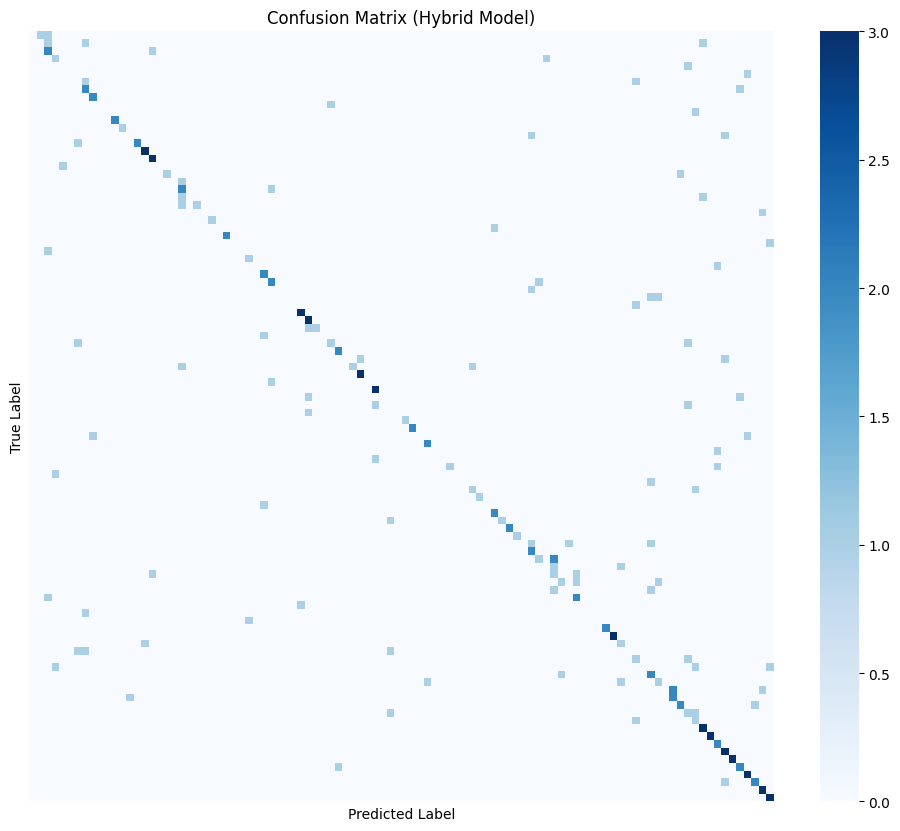


ROC CURVE (One-vs-Rest)


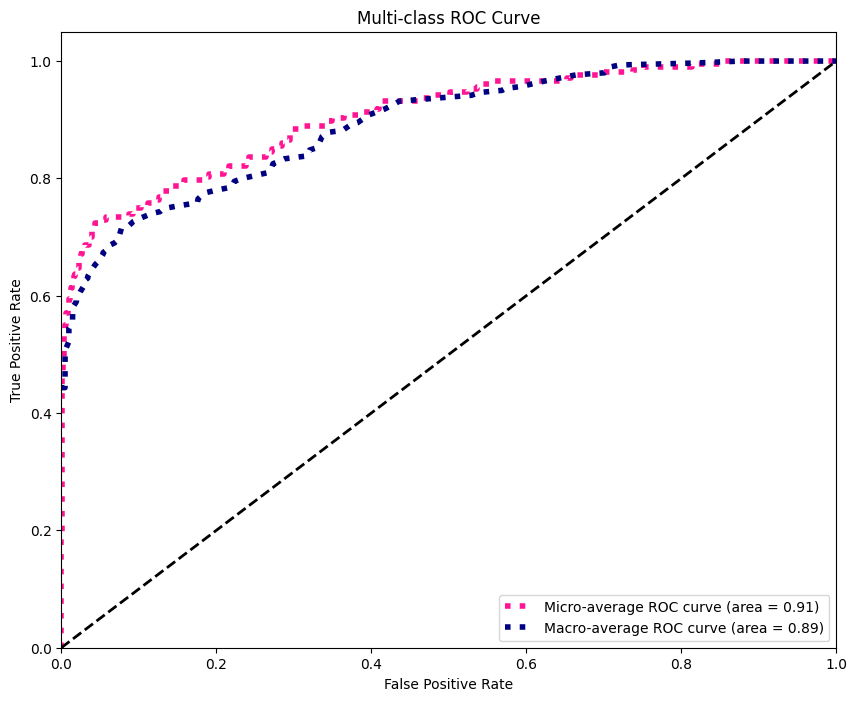

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import LabelBinarizer
from itertools import cycle

# --- 1. Inference Function (Returns Probabilities for ROC) ---
@torch.no_grad()
def get_predictions_and_probs(adapter, classifier, prototypes, loader, few_shot_indices, device):
    adapter.eval()
    classifier.eval()

    few_shot_idx_t = torch.tensor(few_shot_indices, device=device, dtype=torch.long)

    all_labels = []
    all_preds = []
    all_probs = []

    for features, labels, _ in loader:
        features = features.to(device)
        labels = labels.to(device)

        # Forward pass
        adapted = adapter(features)

        # Linear Classifier Logits
        logits_linear = classifier(adapted)

        # Prototype Classifier Logits (Cosine Similarity)
        prototypes_n = F.normalize(prototypes, dim=1)
        adapted_n = F.normalize(adapted, dim=1)
        logits_proto = adapted_n @ prototypes_n.t()

        # Hybrid Logic: Overwrite few-shot columns
        logits = logits_linear.clone()
        logits[:, few_shot_idx_t] = logits_proto[:, few_shot_idx_t]

        # Convert to Probabilities (Softmax)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# --- 2. Run Inference ---
print("Running inference for evaluation...")
# Note: You can swap 'test_loader_custom' with 'val_loader' depending on which set you want to test
y_true, y_pred, y_probs = get_predictions_and_probs(
    adapter,
    classifier,
    prototypes,
    test_loader_custom, # Using the test set from your notebook
    few_shot_label_indices,
    device
)

# --- 3. Basic Metrics (Accuracy, Precision, Recall, F1) ---
print("\n" + "="*30)
print("SCALAR METRICS")
print("="*30)
acc = accuracy_score(y_true, y_pred)
# Weighted average accounts for class imbalance
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f} (Weighted)")
print(f"Recall:    {rec:.4f} (Weighted)")
print(f"F1 Score:  {f1:.4f} (Weighted)")

print("\n" + "="*30)
print("DETAILED CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# --- 4. Confusion Matrix Plot ---
print("\n" + "="*30)
print("CONFUSION MATRIX")
print("="*30)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
# Disable annotations if too many classes to keep it readable
use_annot = True if len(np.unique(y_true)) < 20 else False
sns.heatmap(cm, annot=use_annot, fmt='d', cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('Confusion Matrix (Hybrid Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 5. ROC Curve (Multi-Class One-vs-Rest) ---
print("\n" + "="*30)
print("ROC CURVE (One-vs-Rest)")
print("="*30)

# Binarize the labels for ROC calculation
lb = LabelBinarizer()
y_true_bin = lb.fit_transform(y_true)
n_classes = y_true_bin.shape[1]

# If the test set doesn't have all classes, we might need to pad y_true_bin or adjust logic.
# This assumes y_true_bin matches the shape of y_probs (e.g. 100 classes).
# If y_true misses some classes, LabelBinarizer might create fewer columns.
# We force it to match the probability shape:
if y_true_bin.shape[1] != y_probs.shape[1]:
    all_classes = np.arange(y_probs.shape[1])
    lb = LabelBinarizer()
    lb.fit(all_classes)
    y_true_bin = lb.transform(y_true)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute Micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label='Micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

# Plot Macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.plot(fpr["macro"], tpr["macro"],
         label='Macro-average ROC curve (area = {0:0.2f})'.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()